<a href="https://colab.research.google.com/github/Abishekabi19/ML-and-DL-Project/blob/main/Cervical_cancer/cervical_cancer_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statement
Cervical cancer is one of the leading causes of cancer-related deaths among women worldwide. Early detection is critical for effective treatment and improving survival rates. However, traditional diagnostic methods such as biopsy and cytology can be time-consuming, costly, and require medical expertise. Therefore, there is a need for an automated and intelligent system that can assist in predicting the risk of cervical cancer using patient medical and behavioral data.

The objective of this project is to develop a machine learning and deep learning based prediction system that can analyze patient information such as age, number of sexual partners, smoking habits, contraceptive use, sexually transmitted diseases (STDs), and medical diagnosis history. Using this dataset, the system aims to accurately predict whether a patient is at risk of cervical cancer (based on indicators such as Biopsy results).

This project applies data preprocessing techniques to handle missing values and improve data quality, followed by model training using machine learning algorithms such as Random Forest and Decision Tree, and deep learning models such as Artificial Neural Networks (ANN). K-Fold Cross Validation is used to evaluate model performance and ensure reliability.

The final goal is to identify the most accurate model and deploy it in a practical format (pickle file), enabling fast, reliable, and automated cervical cancer risk prediction. This system can support healthcare professionals in early diagnosis, decision-making, and improving patient outcomes.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/cancer_cervical_50k_extended.csv')
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4,15,1,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
1,15,1,14,1,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
2,34,1,?,1,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
3,52,5,16,4,1,37,37,1,3,0,...,?,?,1,0,1,0,0,0,0,0
4,46,3,21,4,0,0,0,1,15,0,...,?,?,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50963,20,1,16,2,0,0,0,0,0.5,0,...,?,?,0,0,0,0,0,1,0,0
50964,39,3,14,?,?,4,0,?,6,0,...,?,?,0,1,0,0,0,0,0,1
50965,33,4,17,2,0,0,0,0,0.5,0,...,?,?,0,0,0,0,0,1,0,0
50966,18,3,18,4,0,0,0,1,1,?,...,?,?,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50968 entries, 0 to 50967
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 50968 non-null  int64 
 1   Number of sexual partners           50968 non-null  object
 2   First sexual intercourse            50968 non-null  object
 3   Num of pregnancies                  50968 non-null  object
 4   Smokes                              50968 non-null  object
 5   Smokes (years)                      50968 non-null  object
 6   Smokes (packs/year)                 50968 non-null  object
 7   Hormonal Contraceptives             50968 non-null  object
 8   Hormonal Contraceptives (years)     50968 non-null  object
 9   IUD                                 50968 non-null  object
 10  IUD (years)                         50968 non-null  object
 11  STDs                                50968 non-null  ob

In [ ]:
df.replace('?', np.nan, inplace=True)

In [ ]:
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4,15,1,0,0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1,14,1,0,0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1,NaN,1,0,0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5,16,4,1,37,37,1,3,0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3,21,4,0,0,0,1,15,0,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50963,20,1,16,2,0,0,0,0,0.5,0,...,NaN,NaN,0,0,0,0,0,1,0,0
50964,39,3,14,NaN,NaN,4,0,NaN,6,0,...,NaN,NaN,0,1,0,0,0,0,0,1
50965,33,4,17,2,0,0,0,0,0.5,0,...,NaN,NaN,0,0,0,0,0,1,0,0
50966,18,3,18,4,0,0,0,1,1,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50968 entries, 0 to 50967
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 50968 non-null  int64 
 1   Number of sexual partners           49358 non-null  object
 2   First sexual intercourse            50430 non-null  object
 3   Num of pregnancies                  47274 non-null  object
 4   Smokes                              50101 non-null  object
 5   Smokes (years)                      50087 non-null  object
 6   Smokes (packs/year)                 50136 non-null  object
 7   Hormonal Contraceptives             44429 non-null  object
 8   Hormonal Contraceptives (years)     44645 non-null  object
 9   IUD                                 43978 non-null  object
 10  IUD (years)                         43918 non-null  object
 11  STDs                                44583 non-null  ob

In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,1610
First sexual intercourse,538
Num of pregnancies,3694
Smokes,867
Smokes (years),881
Smokes (packs/year),832
Hormonal Contraceptives,6539
Hormonal Contraceptives (years),6323
IUD,6990


In [ ]:
df.drop(['STDs: Time since first diagnosis','STDs: Time since last diagnosis'],axis=1,inplace=True)

In [ ]:
df.dropna(subset=['First sexual intercourse'],inplace=True)

In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,1587
First sexual intercourse,0
Num of pregnancies,3653
Smokes,861
Smokes (years),867
Smokes (packs/year),824
Hormonal Contraceptives,6481
Hormonal Contraceptives (years),6241
IUD,6926


In [ ]:
df['Number of sexual partners']=pd.to_numeric(df['Number of sexual partners'],errors='coerce')
df['Num of pregnancies']=pd.to_numeric(df['Num of pregnancies'],errors='coerce')
df['STDs:HPV']=pd.to_numeric(df['STDs:HPV'],errors='coerce')
df['STDs:Hepatitis B']=pd.to_numeric(df['STDs:Hepatitis B'],errors='coerce')
df['STDs:HIV']=pd.to_numeric(df['STDs:HIV'],errors='coerce')
df['STDs:AIDS']=pd.to_numeric(df['STDs:AIDS'],errors='coerce')
df['STDs:molluscum contagiosum']=pd.to_numeric(df['STDs:molluscum contagiosum'],errors='coerce')
df['STDs:genital herpes']=pd.to_numeric(df['STDs:genital herpes'],errors='coerce')
df['STDs:pelvic inflammatory disease']=pd.to_numeric(df['STDs:pelvic inflammatory disease'],errors='coerce')
df['STDs:syphilis']=pd.to_numeric(df['STDs:syphilis'],errors='coerce')
df['STDs:vulvo-perineal condylomatosis']=pd.to_numeric(df['STDs:vulvo-perineal condylomatosis'],errors='coerce')
df['STDs:vaginal condylomatosis']=pd.to_numeric(df['STDs:vaginal condylomatosis'],errors='coerce')
df['STDs:cervical condylomatosis']=pd.to_numeric(df['STDs:cervical condylomatosis'],errors='coerce')
df['STDs:condylomatosis']=pd.to_numeric(df['STDs:condylomatosis'],errors='coerce')
df['STDs (number)']=pd.to_numeric(df['STDs (number)'],errors='coerce')
df['STDs']=pd.to_numeric(df['STDs'],errors='coerce')
df['IUD (years)']=pd.to_numeric(df['IUD (years)'],errors='coerce')
df['IUD']=pd.to_numeric(df['IUD'],errors='coerce')
df['Hormonal Contraceptives (years)']=pd.to_numeric(df['Hormonal Contraceptives (years)'],errors='coerce')
df['Hormonal Contraceptives']=pd.to_numeric(df['Hormonal Contraceptives'],errors='coerce')
df['Smokes (packs/year)']=pd.to_numeric(df['Smokes (packs/year)'],errors='coerce')
df['Smokes (years)']=pd.to_numeric(df['Smokes (years)'],errors='coerce')
df['Smokes']=pd.to_numeric(df['Smokes'],errors='coerce')
df['First sexual intercourse']=pd.to_numeric(df['First sexual intercourse'],errors='coerce')



In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,1587
First sexual intercourse,0
Num of pregnancies,3653
Smokes,861
Smokes (years),867
Smokes (packs/year),824
Hormonal Contraceptives,6481
Hormonal Contraceptives (years),6241
IUD,6926


In [ ]:
df['IUD (years)'].unique()

array([ 0.  ,  7.  ,   nan,  5.  ,  8.  ,  6.  ,  1.  ,  0.58,  2.  ,
       19.  ,  0.5 , 17.  ,  0.08,  0.25, 10.  , 11.  ,  3.  , 15.  ,
       12.  ,  9.  ,  1.5 ,  0.91,  4.  ,  0.33,  0.41,  0.16,  0.17])

<Axes: >

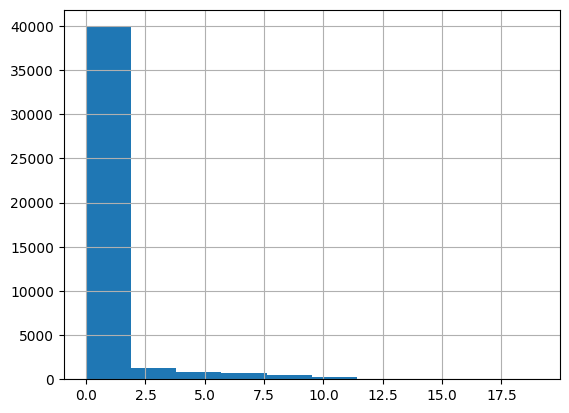

In [ ]:
df['IUD (years)'].hist()

In [ ]:
df['Number of sexual partners'].fillna(df['Number of sexual partners'].mode()[0],inplace=True)
df['Num of pregnancies'].fillna(df['Num of pregnancies'].mode()[0],inplace=True)
df['Smokes'].fillna(df['Smokes'].mode()[0],inplace=True)
df['Smokes (years)'].fillna(df['Smokes (years)'].median(),inplace=True)
df['Smokes (packs/year)'].fillna(df['Smokes (packs/year)'].median(),inplace=True)
df['Hormonal Contraceptives'].fillna(df['Hormonal Contraceptives'].mode()[0],inplace=True)
df['Hormonal Contraceptives (years)'].fillna(df['Hormonal Contraceptives (years)'].median(),inplace=True)
df['IUD'].fillna(df['IUD'].mode()[0],inplace=True)
df['STDs'].fillna(df['STDs'].mode()[0],inplace=True)
df['STDs (number)'].fillna(df['STDs (number)'].mode()[0],inplace=True)
df['STDs:condylomatosis'].fillna(df['STDs:condylomatosis'].mode()[0],inplace=True)
df['STDs:cervical condylomatosis'].fillna(df['STDs:cervical condylomatosis'].mode()[0],inplace=True)
df['STDs:vaginal condylomatosis'].fillna(df['STDs:vaginal condylomatosis'].mode()[0],inplace=True)
df['STDs:vulvo-perineal condylomatosis'].fillna(df['STDs:vulvo-perineal condylomatosis'].mode()[0],inplace=True)
df['STDs:syphilis'].fillna(df['STDs:syphilis'].mode()[0],inplace=True)
df['STDs:pelvic inflammatory disease'].fillna(df['STDs:pelvic inflammatory disease'].mode()[0],inplace=True)
df['STDs:genital herpes'].fillna(df['STDs:genital herpes'].mode()[0],inplace=True)
df['STDs:molluscum contagiosum'].fillna(df['STDs:molluscum contagiosum'].mode()[0],inplace=True)
df['STDs:AIDS'].fillna(df['STDs:AIDS'].mode()[0],inplace=True)
df['STDs:HIV'].fillna(df['STDs:HIV'].mode()[0],inplace=True)
df['STDs:Hepatitis B'].fillna(df['STDs:Hepatitis B'].mode()[0],inplace=True)
df['STDs:HPV'].fillna(df['STDs:HPV'].mode()[0],inplace=True)
df['IUD (years)'].fillna(df['IUD (years)'].median(),inplace=True)




/tmp/ipython-input-1216231191.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Number of sexual partners'].fillna(df['Number of sexual partners'].mode()[0],inplace=True)
/tmp/ipython-input-1216231191.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing

In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50430 entries, 0 to 50967
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 50430 non-null  int64  
 1   Number of sexual partners           50430 non-null  float64
 2   First sexual intercourse            50430 non-null  int64  
 3   Num of pregnancies                  50430 non-null  float64
 4   Smokes                              50430 non-null  float64
 5   Smokes (years)                      50430 non-null  float64
 6   Smokes (packs/year)                 50430 non-null  float64
 7   Hormonal Contraceptives             50430 non-null  float64
 8   Hormonal Contraceptives (years)     50430 non-null  float64
 9   IUD                                 50430 non-null  float64
 10  IUD (years)                         50430 non-null  float64
 11  STDs                                50430 non-

In [ ]:
df.duplicated().sum()

np.int64(1819)

In [ ]:
df.drop_duplicates(inplace=True)

<Axes: >

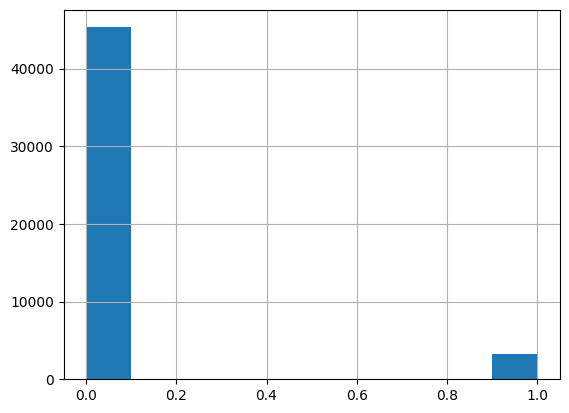

In [ ]:
df['Biopsy'].hist()

In [ ]:
X=df.drop(columns=['Biopsy'])
y=df['Biopsy']

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
X_smote,y_smote=smote.fit_resample(X,y)

df_smote=pd.concat([pd.DataFrame(X_smote,columns=X.columns),
                    pd.Series(y_smote,name=y.name)],axis=1)

df=df_smote

<Axes: >

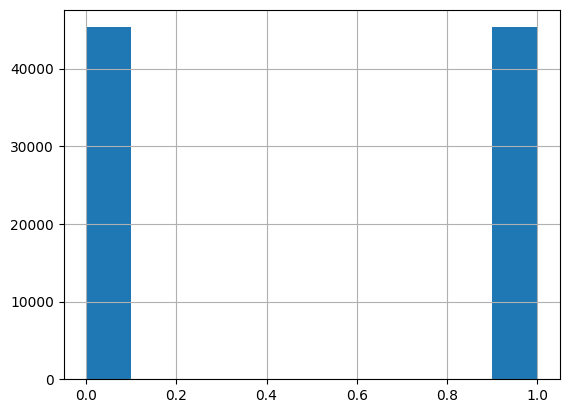

In [ ]:
df['Biopsy'].hist()

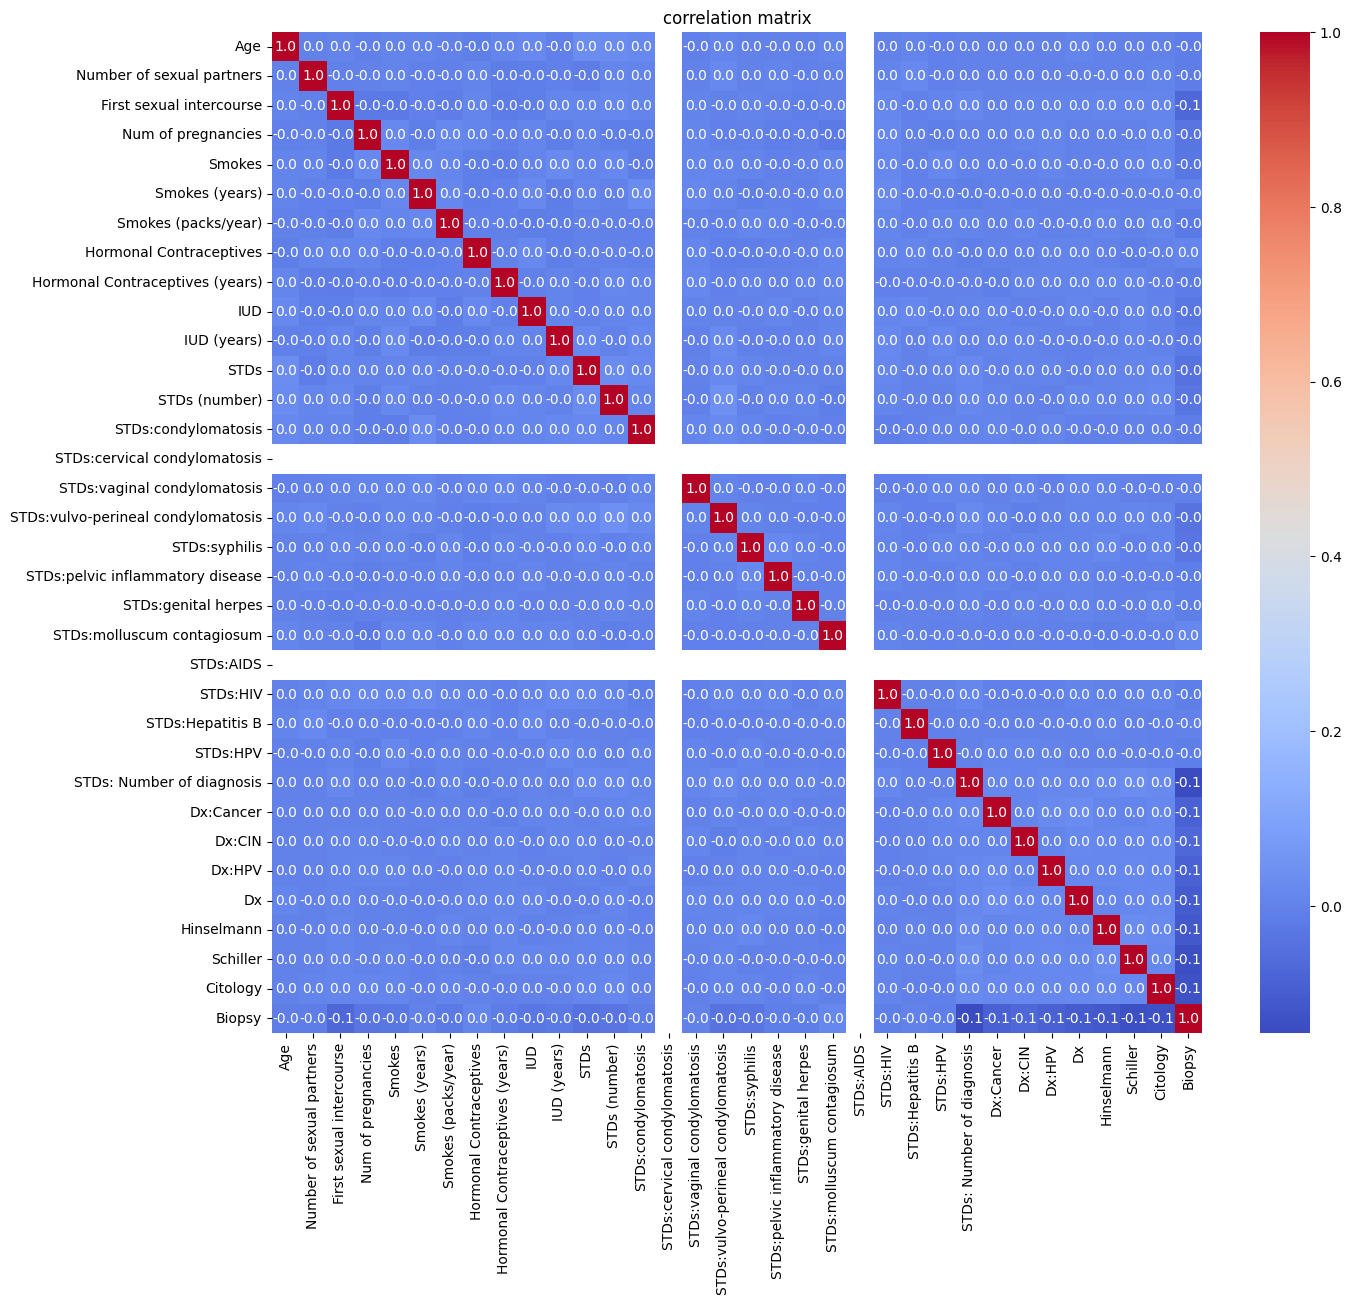

In [ ]:
plt.figure(figsize=(15,13))
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

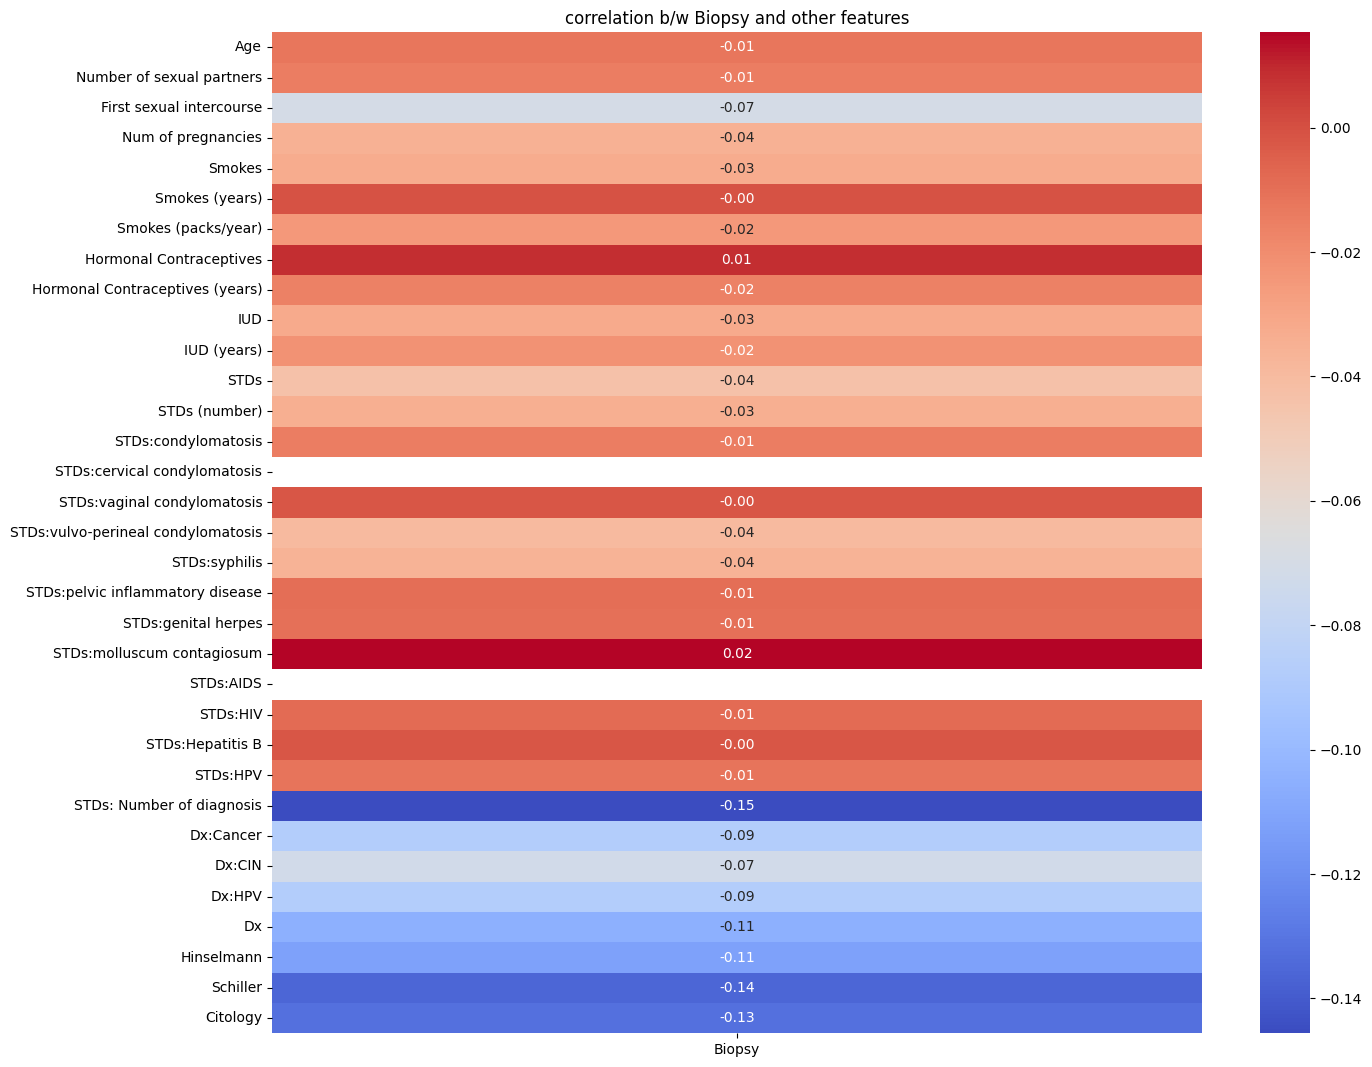

In [ ]:
plt.figure(figsize=(15,13))
biopsy_corr=df.corr()['Biopsy']
biopsy_corr=biopsy_corr.drop('Biopsy')
sns.heatmap(biopsy_corr.to_frame(),annot=True,fmt='0.2f',cmap='coolwarm',annot_kws={'size':10})
plt.title('correlation b/w Biopsy and other features')
plt.show()

In [ ]:
df.drop(['STDs:HPV','STDs:Hepatitis B','STDs:HIV','STDs:genital herpes','STDs:pelvic inflammatory disease','STDs:vaginal condylomatosis',
         'STDs:condylomatosis','Hormonal Contraceptives (years)','Hormonal Contraceptives','Smokes (years)','Age','Number of sexual partners',
         'Smokes (packs/year)','IUD (years)','STDs:AIDS','STDs:cervical condylomatosis'],axis=1,inplace=True)

In [ ]:
df

,First sexual intercourse,Num of pregnancies,Smokes,IUD,STDs,STDs (number),STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:molluscum contagiosum,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,15,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,0
1,14,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,0
2,16,4.000000,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,0,1,0,0,0,0,0
3,21,4.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,0
4,23,2.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90637,16,1.296459,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1
90638,13,1.000000,0.725128,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1
90639,17,1.972105,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1
90640,14,1.000000,0.559792,0.0,0.0,0.0,0.000000,0.0,0.0,1,0,0,0,0,0,0,0,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
features=['First sexual intercourse','Num of pregnancies','Smokes',	'IUD','STDs',	'STDs (number)',	'STDs:vulvo-perineal condylomatosis',
          'STDs:syphilis','STDs:molluscum contagiosum','STDs: Number of diagnosis',	'Dx:Cancer',	'Dx:CIN',	'Dx:HPV',	'Dx',	'Hinselmann',	'Schiller',	'Citology']

scaled=scale.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled,columns=features)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x=scaled_df
y=df['Biopsy']

kf=KFold(n_splits=5,shuffle=True,random_state=42)
model=LogisticRegression()

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]

  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_pred,y_test)
  print(f'Accuracy:{acc}')

  if acc>best_accuracy:
    best_accuracy=acc
    best_fold=fold
    best_x_train=x_train
    best_x_test=x_test
    best_y_train=y_train
    best_y_test=y_test
    best_y_pred=y_pred
print(f'\n Best fold:{best_fold} with accuracy:{best_accuracy}')

Accuracy:0.636163053670914
Accuracy:0.6368249765568977
Accuracy:0.6334399823477493
Accuracy:0.638018534863195
Accuracy:0.6336606354810238

 Best fold:4 with accuracy:0.638018534863195


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8280560458958517

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8298212709620476

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(256,activation='relu',input_shape=(17,)))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_x_train,best_y_train,epochs=145,batch_size=32)

Epoch 1/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8042 - loss: 0.3659
Epoch 2/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8111 - loss: 0.3572
Epoch 3/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8093 - loss: 0.3581
Epoch 4/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8106 - loss: 0.3604
Epoch 5/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8069 - loss: 0.3598
Epoch 6/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8050 - loss: 0.3648
Epoch 7/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8079 - loss: 0.3606
Epoch 8/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8070 - loss: 0.3604
Epoch 9/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8054 - loss: 0.3624
Epoch 10/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8093 - loss: 0.3581
Epoch 11/145
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8037 - loss: 0.3644
Epoch 12/145
2267/2

In [ ]:
y_pred=model.predict(best_x_test)
loss,accuracy=model.evaluate(best_x_test,best_y_test)
print(f'Accuracy:{accuracy}')

567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8331 - loss: 0.8380
Accuracy:0.804225504398346


In [ ]:
import pickle
with open('cervical cancer ML Model.pkl',"wb") as file:
  pickle.dump(model,file)

In [ ]:
with open('/content/cervical cancer ML Model.pkl',"rb") as file:
  load_data=pickle.load(file)

In [ ]:
best_x_test

,First sexual intercourse,Num of pregnancies,Smokes,IUD,STDs,STDs (number),STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:molluscum contagiosum,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology
10,0.318182,0.272727,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,0.363636,0.181818,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,0.227273,0.727273,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,0.363636,0.363636,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,0.318182,0.272727,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90616,0.272727,0.181818,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90618,0.136364,0.060281,1.000000,0.663087,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90622,0.454545,0.104301,0.852691,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90634,0.181818,0.181818,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
a=load_data.predict(np.array([[0.363636,	0.181818,	0.000000,	0.000000,	0.0,	0.0,	0.0,	0.0,	0.0,	0.000000,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0]]))
print(np.round(a))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[0.]]


In [ ]:
b=load_data.predict(np.array([[0.181818,	0.090909,	0.559792,	0.000000,	0.0,	0.0,	0.0,	0.0,	0.0,	0.333333,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0	,0.0]]))
print(np.round(b))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[1.]]


# Conclusion

In this project, a Cervical Cancer Prediction System was successfully developed using K-Fold cross-validation along with Machine Learning and Deep Learning techniques. During the Machine Learning phase, Decision Tree and Random Forest models were implemented and evaluated, while a Deep Learning model was developed for comparison. The experimental results demonstrated that the Machine Learning models achieved higher prediction accuracy than the Deep Learning model. Among all the evaluated approaches, the Random Forest algorithm consistently delivered the best performance in terms of accuracy and reliability. Based on these findings, the Random Forest model was selected as the final model. To support efficient deployment and future reuse, the trained model was saved in pickle format, enabling seamless integration into real-world applications and further enhancements of the system